In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
from matplotlib import pyplot as plt
import torchvision

In [ ]:
transform=transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,), (0.5,))])
train_dataset = dsets.MNIST(root='./data',
                            train=True,
                            transform=transform,
                            download=True)

test_dataset = dsets.MNIST(root='./data',
                           train=False,
                           transform=transform)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:11<00:00, 900473.45it/s] 


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 135054.10it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:01<00:00, 1275251.69it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 6113776.88it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [ ]:
print("training dataset data (images):", train_dataset.train_data.size())
print("training labels:", train_dataset.train_labels.size())
print("testing data(images):", test_dataset.test_data.size())
print("testing labels:", test_dataset.test_labels.size())

training dataset data (images): torch.Size([60000, 28, 28])
training labels: torch.Size([60000])
testing data(images): torch.Size([10000, 28, 28])
testing labels: torch.Size([10000])


/usr/local/lib/python3.10/dist-packages/torchvision/datasets/mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")
/usr/local/lib/python3.10/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.10/dist-packages/torchvision/datasets/mnist.py:81: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
/usr/local/lib/python3.10/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


In [ ]:
batch_size = 128
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)

torch.Size([128, 1, 28, 28])


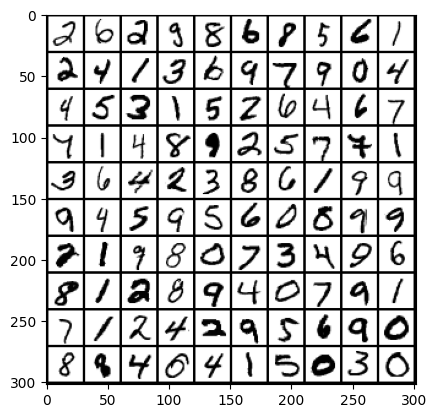

In [ ]:
samples_batch, labels = next(iter(train_loader))
print(samples_batch.size()) #torch.Size([128, 1, 28, 28])

def imshow_grey(img):
    plt.imshow(img.permute(1,2,0),cmap="Greys")
    plt.show()

imshow_grey(torchvision.utils.make_grid(256-samples_batch[:100], nrow=10, normalize=True))


In [ ]:
# hyper-parameters
input_size = samples_batch.size()[3]    # the number of columns: 28
seq_length = samples_batch.size()[2]   # the number of rows: 28
batch_size = samples_batch.size()[0]   # the number of images: 128
hidden_size = 120    # output size of the hidden state
num_layers = 1       # number of layers for the hidden state
num_classes = 10     # number of output classes
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print('input_size: {}, seq_length: {}, batch_size: {}'.format(input_size, seq_length, batch_size))
print('device: ', device)

input_size: 28, seq_length: 28, batch_size: 128
device:  cuda:0


In [ ]:
'''
build RNN model using nn.RNN()
classtorch.nn.RNN(input_size, hidden_size, num_layers=1, nonlinearity='tanh',
bias=True, batch_first=False, dropout=0.0, bidirectional=False,
device=None, dtype=None)
--input_size: The number of features in the input x
--hidden_size: The number of features in the hidden state h
--num_layers: Number of recurrent layers.
  E.g., num_layers=2 would mean stacking two RNNs together to form a stacked RNN,
-- nonlinearity: can be either 'tanh' or 'relu'. Default: 'tanh'
-- batch_first: If True, then the input and output tensors are provided as (batch, seq, feature).
  Default: False
  --bidirectional: If True, becomes a bidirectional RNN. Default: False
'''
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(RNNModel, self).__init__()
        # Hidden state dimension
        self.hidden_size = hidden_size
        # Number of hidden layers
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, nonlinearity='relu')
        # Output layer for classification
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        out, hn= self.rnn(x)
        # -- out (batch_size, seq_length, hidden_size)
        #    for all hidden_states at different time steps
        # -- hn (1, batch_size, hidden_size):
        #   containing the final hidden state for each element in the batch

        # only need the last time step hidden states!
        hn = torch.squeeze(hn)
        # (1, batch_size, hidden_size) reshape to:  (batch_size, hidden_size)

        out = self.fc(hn)
        # out.size() --> batch_size, 10
        return out

In [ ]:

model = RNNModel(input_size, hidden_size, num_layers, num_classes).to(device)

In [ ]:
samples_input = samples_batch.view(-1, seq_length, input_size).to(device) # fit the model input shape
print("shape of samples_input:", samples_input.size())  # torch.Size([128, 28, 28])
output = model(samples_input)
print("shape of output:", output.size())  # torch.Size([128, 10])

shape of samples_input: torch.Size([128, 28, 28])
shape of output: torch.Size([128, 10])


In [ ]:

print(output[0])
pytorch_total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(pytorch_total_params)

tensor([-0.1099,  0.1298,  0.0321,  0.0534, -0.0996, -0.1085,  0.0979, -0.0326,
        -0.1537, -0.0329], device='cuda:0', grad_fn=<SelectBackward0>)
48010


In [ ]:
model = RNNModel(input_size, hidden_size, num_layers, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
learning_rate=0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
#learning_rate=0.0001
#optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

num_epochs = 40
iter = 0
loss_list = []
accuracy_list = []

for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        model.train()
        # fit input tensor shape with gradient required: (batch, seq_dim, x_dim)
        images = images.view(-1, seq_length, input_size).requires_grad_().to(device)
        labels = labels.to(device)

        # Clear gradients w.r.t. parameters
        optimizer.zero_grad()

        # Forward pass to get output/logits
        # outputs.size(): (batch, 10)
        outputs = model(images)

        # Calculate Loss: softmax and cross entropy loss
        loss = criterion(outputs, labels)

        # backward
        loss.backward()

        # Updating parameters
        optimizer.step()

        iter += 1

        if iter % 100 == 0:
            model.eval()
            correct = 0
            total = 0
            # iterate batch by batch over test set
            for images, labels in test_loader:
                # Load images
                images = images.view(-1, seq_length, input_size).to(device)
                labels = labels.to(device)

                # Forward pass
                outputs = model(images)

                # Get predictions from the maximum value
                _, predicted = torch.max(outputs.data, 1)

                # Total number of labels
                total += labels.size(0)

                # Total correct predictions
                correct += (predicted == labels).sum()

            accuracy = 100 * correct / total

            # Print and save losss and accuracy
            print('Iteration: {}. Loss: {}. Accuracy: {}'.format(iter, loss.item(), accuracy))
            loss_list.append(loss.item())
            accuracy_list.append(accuracy)

Iteration: 100. Loss: 2.290172815322876. Accuracy: 11.399999618530273
Iteration: 200. Loss: 2.2888529300689697. Accuracy: 11.799999237060547
Iteration: 300. Loss: 2.2904212474823. Accuracy: 15.00999927520752
Iteration: 400. Loss: 2.286027669906616. Accuracy: 14.869999885559082
Iteration: 500. Loss: 2.2735421657562256. Accuracy: 15.779999732971191
Iteration: 600. Loss: 2.251798629760742. Accuracy: 20.760000228881836
Iteration: 700. Loss: 2.180872917175293. Accuracy: 30.509998321533203
Iteration: 800. Loss: 2.0419018268585205. Accuracy: 32.80999755859375
Iteration: 900. Loss: 1.7640854120254517. Accuracy: 39.14999771118164
Iteration: 1000. Loss: 1.5019826889038086. Accuracy: 49.29999923706055
Iteration: 1100. Loss: 1.2234103679656982. Accuracy: 51.64999771118164
Iteration: 1200. Loss: 1.2788732051849365. Accuracy: 56.28999710083008
Iteration: 1300. Loss: 0.9761595726013184. Accuracy: 57.82999801635742
Iteration: 1400. Loss: 0.8988968729972839. Accuracy: 66.62999725341797
Iteration: 1500.

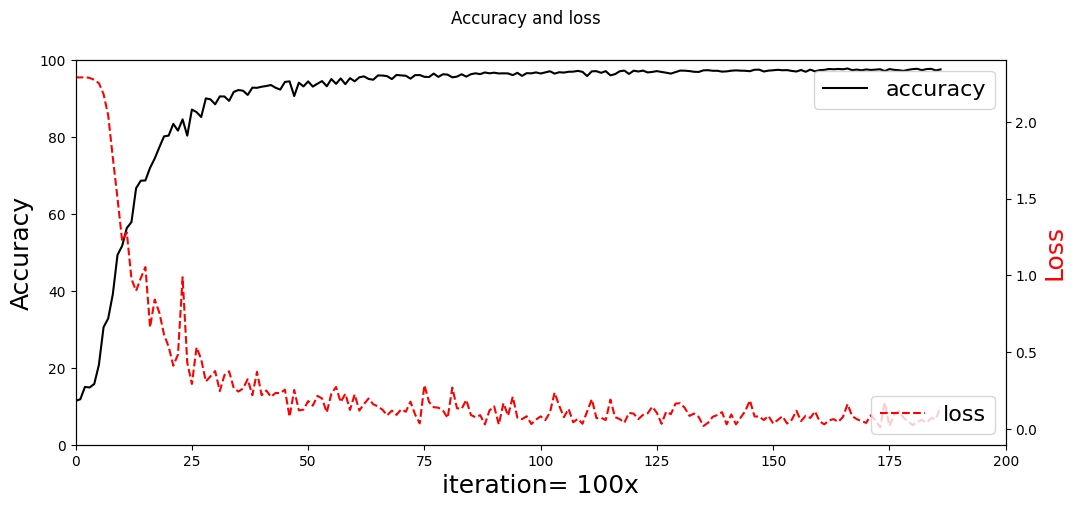

In [ ]:
# plot accuracy and loss in one plot.

from matplotlib import pyplot as plt

fig = plt.figure(figsize=(12,5))
fig.suptitle("Accuracy and loss")
ax1 = fig.add_subplot()
ax2 = ax1.twinx()
accuracy_list = torch.Tensor(accuracy_list) # if GPU was used for training
ax1.plot(accuracy_list, color='black', label='accuracy')
ax1.set_xlabel('iteration= 100x', fontsize=18)
ax1.set(xlim=(0, 200), ylim=(0, 100))

ax2.plot(loss_list, color='red', linestyle='dashed', label='loss')
ax2.set(ylabel="Loss")

ax1.set_ylabel("Accuracy", fontsize=18)
ax2.set_ylabel("Loss", color='red', fontsize=18)

ax1.legend(loc = 'upper right', fontsize=16)
ax2.legend(loc = 'lower right', fontsize=16)

plt.show()